# Домашнее задание 6. Графовые нейронные сети: проектирование и обучение простой GNN под прикладную задачу

В этом домашнем задании вы шаг за шагом:

- сформулируете прикладную задачу в графовой постановке;
- реализуете и обучите простую GCN-модель для классификации узлов;
- реализуете и обучите упрощенный вариант GraphSAGE и сравните его с GCN;
- добавите graph pooling и решите простую graph-level задачу на синтетических графах.

Все задачи — кодовые, с акцентом на понимание механики message passing, форм тензоров
и влияния архитектурных решений на качество моделей.


## Структура домашней работы

Домашнее задание состоит из 9 задач, разделенных на три уровня сложности:

- Простые задачи: 1–4.
- Средние задачи: 5–7.
- Сложные задачи: 8–9.

Задачи идут от базового представления графов к полноценным графовым нейронным сетям
для классификации узлов и графов.


## Цели занятия

После выполнения этого домашнего задания вы сможете:

1. Понять, как формулировать прикладную задачу в виде графовой модели с узлами, ребрами и признаками.
2. Освоить базовую реализацию GCN-слоя и message passing в матричной форме.
3. Научиться обучать и отлаживать простую GCN для классификации узлов на синтетических данных.
4. Проанализировать отличия GraphSAGE от GCN и влияние разных типов агрегации соседей.
5. Сравнить узловые и графовые постановки через добавление pooling-уровня и graph-level классификатора.
6. Интерпретировать полученные эмбеддинги узлов и графов и сделать практические выводы по выбору архитектуры.


## Теоретическая часть

### Граф как структура данных

Граф $G = (V, E)$ задается множеством узлов $V$ и ребер $E$. Узлам и ребрам часто сопоставляют
признаки: матрица признаков узлов $X \in \mathbb{R}^{N \times D}$, где $N$ — число узлов, $D$ — размерность признаков.
Структура графа кодируется матрицей смежности $A \in \mathbb{R}^{N \times N}$, где $A_{ij} = 1$, если есть ребро между
узлами $i$ и $j$, и $0$ иначе.

### Message passing и GNN

Идея графовых нейронных сетей: узлы итеративно обмениваются информацией с соседями. На каждом слое
обновление признаков узла можно записать в общем виде как
$$h_i^{(k+1)} = \mathrm{UPDATE}\Bigl(h_i^{(k)}, \mathrm{AGGREGATE}(\{h_j^{(k)} : j \in \mathit{N}(i)\})\Bigr),$$
где $\mathit{N}(i)$ — множество соседей узла $i$. В матричной форме это приводит к операциям вида
$H^{(k+1)} = \sigma(\tilde{A} H^{(k)} W^{(k)})$, где $\tilde{A}$ — нормализованная матрица смежности.

### GCN и GraphSAGE

- **GCN** использует фиксированную нормализующую матрицу $\tilde{A}$ и агрегирует соседей через
  умножение $\tilde{A} H$.
- **GraphSAGE** явно задает функцию агрегации (mean / sum / max) и обновляет признак узла как функцию
  от его собственного признака и агрегированных признаков соседей, что делает модель более гибкой
  и удобной для индуктивных сценариев.

В этом задании мы будем реализовывать простые варианты этих идей, не зависящие от конкретных фреймворков
для графов, используя только NumPy / PyTorch и NetworkX.

## Настройка окружения

In [1]:
# Импорт
import random

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используемое устройство:", DEVICE)


Используемое устройство: cuda


---

# ПРОСТЫЕ ЗАДАЧИ (1–4)

В этих задачах мы научимся представлять графы в виде матриц, задавать признаки узлов
и реализовывать один шаг агрегирования признаков соседей.


## Задача 1. Построение графа и матрицы смежности

### Постановка задачи

1. Сконструировать небольшой неориентированный граф с помощью NetworkX.
2. Получить его матрицу смежности в виде NumPy-массива.
3. Визуализировать граф и проверить согласованность между матрицей и рисунком.

### Теоретический минимум

- Матрица смежности полностью задает структуру графа.
- Степень узла равна сумме элементов соответствующей строки или столбца матрицы \(A\).


Форма матрицы смежности A: (8, 8)
[[0. 1. 1. 0. 0. 0. 0. 0.]
 [1. 0. 1. 1. 1. 0. 0. 0.]
 [1. 1. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 1. 0. 0. 0.]
 [0. 1. 1. 1. 0. 1. 1. 0.]
 [0. 0. 0. 0. 1. 0. 1. 1.]
 [0. 0. 0. 0. 1. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]]


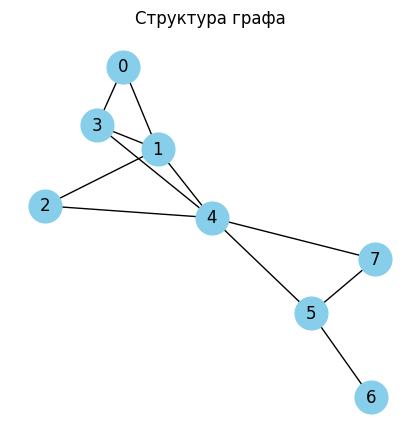

Степени узлов: [2. 4. 3. 2. 5. 3. 2. 1.]


In [2]:
# Задача 1. Построение графа и матрицы смежности

# DONE: Создайте граф G с помощью nx.Graph()
G = nx.Graph()
nodes = [0, 1, 3, 2, 4, 5, 7, 6]
G.add_nodes_from(nodes)

# DONE: Добавьте ребра. Используйте набор из 10–12 ребер на 6–8 узлов.
# Пример структуры: G.add_edges_from([(u1, v1), (u2, v2), ...])
G.add_edges_from([(0, 3), (0, 1), (3, 1), (3, 4), (1, 2), (1, 4),
                  (2, 4), (4, 7), (4, 5), (7, 5), (5, 6), ])

# DONE: Получите матрицу смежности A в виде NumPy-массива (dtype=np.float32)
A = nx.adjacency_matrix(G, dtype=np.float32).toarray()
print("Форма матрицы смежности A:", A.shape)
print(A)

# DONE: Визуализируйте граф (с метками узлов)
plt.figure(figsize=(4, 4))
pos = nx.spring_layout(G, seed=SEED)  # граф-пружинка
nx.draw(G,
        pos=pos,
        with_labels=True,
        hide_ticks=True,
        node_color="skyblue",
        node_size=555,)
plt.title("Структура графа")
plt.show()

# DONE: Вычислите степени всех узлов через матрицу смежности
degrees = A.sum(axis=1)

print("Степени узлов:", degrees)

**Интерпретация:**
 1. Порядок, в котором указываются вершины, имеет значение для отрисовки. Мне удалось подобрать такой-же порядок, как в примере, чтобы получить аналогичное отображение =)  
 1. Порядок, в котором указываются рёбра, значения для отрисовки не имеет
 1. Рёбра задаются кортежем (вершина1, вершина2). Для неориентированных графов порядок не имеет значения
 1. Пакет `networkx` имеет несколько методов для отображения графа. Некоторые из них:
    - **draw_random** - случайное размещение узлов
    - **draw_spring** - пружинная модель (force-directed)
    - **draw_spectral** - спектральная компоновка
    - **draw_shell** - многослойное круговое размещение
    - **draw_kamada_kawai** - энергетическая минимизация (аналог spring, но другой алгоритм)
    - **draw_planar** - плоская укладка без пересечений рёбер (если граф планарен)
    - **draw_geometric** - если узлы имеют координаты
 1. Метод `networkx.adjacency_matrix(G)` строит матрицу смежности вершин, которая отражает наличие связи между вершинами. У неориентированных графов матрица смежности симметрична
 1. **Степень всех узлов** показывает сколько связей существует у каждой вершины. _**В неориентированном графе**_ - просто число соседей. _**В ориентированном**_ - две степени: исходящая (сумма по строкам, сколько стрелок выходит) и входящая (сумма по столбцам, сколько входит).

 1. Для каждого грфа строится 3 матрицы:
   - $A$ - матрица смежности ($N \times N$, где $N$ - количество узлов)
   - $X$ - матрица признаков узлов ($D \times N$)
   - $E$ - матрица признаков ребер ($D \times E$)  
 Каждая из этих матриц фиксирует определенный аспект графа - структуру, свойства узлов и свойства связей соответственно.

## Задача 2. Признаки узлов и агрегирование соседей

### Постановка задачи

1. Задать простые числовые признаки для каждого узла (например, константа и степень).
2. Реализовать агрегирование признаков соседей через умножение \(A X\).
3. Проинтерпретировать полученные агрегированные признаки.

### Теоретический минимум

- Матрица признаков $(X \in \mathbb{R}^{N×D})$ хранит по строкам признаки узлов.
- Умножение \(A X\) дает для каждого узла сумму признаков его соседей.


In [3]:
# Задача 2. Признаки узлов и агрегирование соседей

num_nodes = A.shape[0]

# DONE: Создайте матрицу признаков X формы (N, 2).
# Признак 1: константа (единица для каждого узла)
# Признак 2: нормированная степень узла (от 0 до 1)
degrees = A.sum(axis=1)
deg_norm = degrees / np.max(degrees)

X = np.column_stack([np.ones(num_nodes), deg_norm]).astype(np.float32)  # форма: (N, 2), dtype=np.float32
print("Форма X:", X.shape)
print("Первые строки X:", X[:5])

# DONE: Выполните шаг агрегирования: AX = A @ X
AX = A @ X
print("Форма AX:", AX.shape)
print("Первые строки AX (агрегированные признаки соседей):", AX[:5])

# DONE: Проверьте вручную для нескольких узлов:
# выведите список соседей и соответствующий агрегированный признак
nodes = {v: list(G.neighbors(v)) for _, v in enumerate(list(G.nodes()))}
for g_item in sorted(
    [(*elem, idx) for idx, elem in enumerate(tuple(nodes.items()))],
    key=lambda x: x[0]
    ):
    print(f"Узел {g_item[0]}:",
          f"соседи {g_item[1]},",
          f"агрегированный признак =", AX[g_item[2]])

Форма X: (8, 2)
Первые строки X: [[1.  0.4]
 [1.  0.8]
 [1.  0.6]
 [1.  0.4]
 [1.  1. ]]
Форма AX: (8, 2)
Первые строки AX (агрегированные признаки соседей): [[2.        1.4000001]
 [4.        2.4      ]
 [3.        2.2      ]
 [2.        1.8      ]
 [5.        2.8000002]]
Узел 0: соседи [3, 1], агрегированный признак = [2.        1.4000001]
Узел 1: соседи [0, 3, 2, 4], агрегированный признак = [4.  2.4]
Узел 2: соседи [1, 4], агрегированный признак = [2.  1.8]
Узел 3: соседи [0, 1, 4], агрегированный признак = [3.  2.2]
Узел 4: соседи [3, 1, 2, 7, 5], агрегированный признак = [5.        2.8000002]
Узел 5: соседи [4, 7, 6], агрегированный признак = [3.  1.6]
Узел 6: соседи [5], агрегированный признак = [1.  0.6]
Узел 7: соседи [4, 5], агрегированный признак = [2.  1.6]


**Интерпретация:**
 - Объект networkx (`nx`) содержит в себе информацию о всех соседях каждого узла (вершины) графа `G`. Каждый сосед определяется наличие ребра между узлами.  
 - Агрегированный признак `AX` первым столбцом содержит в себе количество соседей для узла, а вторым - сумму нормированных степеней этих соседей, например, для узла 1 соседи 0, 2, 3, 4, их степени = 0.4, 0.6, 0.4, 1., а сумма степеней = 2.4. Предположу, что так мы получаем уникальное представление каждого узла, которое учитывает как локальную степень, так и "важность" соседей.
 - Цикл for неверно выводил информацию, поскольку для узла 7 неверно было вычислено количество соседей (должно быть 2). Я немного переписал функцию, чтобы получить качественный результат.  

## Задача 3. Нормализованный шаг GCN

### Постановка задачи

1. Добавить к графу петли (self-loops).
2. Построить нормализованную матрицу смежности $\tilde{A} = D^{-1/2}(A + I)D^{-1/2}$.
3. Выполнить шаг $H = \tilde{A} X W$ и проверить формы тензоров.

### Теоретический минимум

- Добавление петель позволяет узлу сохранить собственные признаки при обновлении.
- Нормализация по степеням стабилизирует масштаб активаций.

### Из синхрона
 - $\hat A = A + I$ - матрица смежности с петлями (вершина учитывает и себя)
 - $\hat D$ - диагональная метрица степеней $\hat A$
 - $D^{-1/2}\hat{A}D^{-1/2}$ - симметричная нормализация (средневзвешенная агрегация)

In [4]:
# Задача 3. Нормализованный шаг GCN

# DONE: Добавьте петли: A_hat = A + I
I = np.eye(A.shape[0], dtype=np.float32)
A_hat = A + I

# DONE: Вычислите диагональную матрицу степеней D_hat для A_hat
D_hat = A_hat.sum(axis=1)

# DONE: Постройте D^{-1/2} как диагональную матрицу
# Подсказка: добавьте 1e-8, чтобы избежать деления на ноль
D_inv_sqrt = np.diag(1. / (np.sqrt(D_hat) + 1e-8))

# DONE: Нормализуйте: A_norm = D_inv_sqrt @ A_hat @ D_inv_sqrt
A_norm = D_inv_sqrt @ A_hat @ D_inv_sqrt
print("Форма A_norm:", A_norm.shape)

# DONE: Задайте случайную матрицу весов W формы (in_dim, out_dim)
in_dim = X.shape[1]
out_dim = 4
W = np.random.randn(in_dim, out_dim).astype(np.float32) * 0.1 # масштаб ~0.1
print("Форма W:", W.shape)

# DONE: Выполните один шаг GCN: H = A_norm @ X @ W
H = A_norm @ X @ W
print("Форма H:", H.shape)
print("Первые строки H:", H[:5].round(7))


Форма A_norm: (8, 8)
Форма W: (2, 4)
Форма H: (8, 4)
Первые строки H: [[ 0.0317068 -0.0241836  0.138039   0.1734351]
 [ 0.0397604 -0.0315198  0.1806154  0.2234107]
 [ 0.0328184 -0.0285452  0.1650018  0.1969531]
 [ 0.0276122 -0.0249145  0.1444777  0.1701634]
 [ 0.0435675 -0.0344634  0.1974407  0.244433 ]]


**Интерпретация:**
- Матрица смежностей всегда квадратная для графа с $N$ вершинами, её размерность $N \times N$  
- Для матрицы $I$ нужно взять размер $N$  
- Матрица смежности с петлями $\hat A$ необходима для учета собственной вершины при агрегациях  
- Степени в модифицированном графе $\hat D$ необходим для вычисления векторов степеней вершин в модифицированном графе с петлями
- Матрица `D_inv_sqrt` диагональная, но степени хранятся на диагонали; матричное умножение $D^{-1/2}\hat{A}D^{-1/2}$ симметрично нормализует $\hat A$, делая её не стохастической, а симметричной, что в результате даёт `A_norm`
- Добавление 1e-8(машинное слово) к корню из степеней необходимо для численной устойчивости (защита от деления на 0), если какой-то узел изолирован (степень 0)
- Нормализованная матрица `A_norm` имеет строки, сумма которых не равна 1 (в отличие от случайной матрицы), но собственные значения лежат в [-1,1], что повысит стабильность обучения  
- Формула $H = A_{norm} \cdot X \cdot W$ показывает, что сначала агрегируются признаки соседей с учётом нормализации, затем применяется линейное преобразование с использованием весов  
- Матрица весов $W$ обучаема, но в учебном примере задана случайными значениями; в реальном GCN её инициализируют специальным образом (например, Глоро (из интернетов))  
- Выход $H$ имеет размерность $(N \times out\_dim)$ - это новые признаки узлов после одного слоя GCN  

## Задача 4. Простая узловая задача на синтетическом графе

### Постановка задачи

1. Сгенерировать синтетический граф с двумя группами узлов (два класса).
2. Задать базовые признаки узлов.
3. Реализовать один шаг GCN (без обучения) и визуализировать узлы в 2D-пространстве признаков.

### Теоретический минимум

- Даже один шаг message passing может сделать узлы одного класса более похожими друг на друга
  в скрытом пространстве.


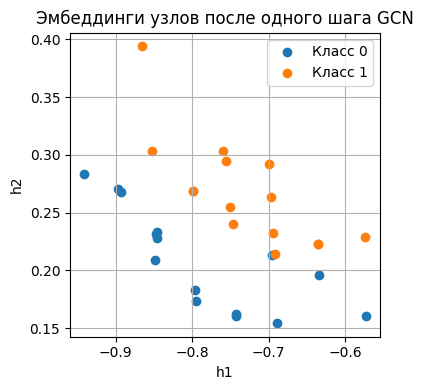

In [5]:
# Задача 4. Узловая задача и визуализация эмбеддингов

# DONE: Сгенерируйте граф с двумя кластерами по 15 узлов
# nx.planted_partition_graph(l=..., k=..., p_in=..., p_out=..., seed=SEED)
G2 = nx.planted_partition_graph(l=2, k=15, p_in=0.4, p_out=0.02, seed=SEED)
A2 = nx.to_numpy_array(G2, dtype=np.float32)
num_nodes2 = A2.shape[0]

# DONE: Задайте метки узлов: первые 15 — класс 0, вторые 15 — класс 1
labels2 = np.array(([0] * 15) + ([1] * 15))

# DONE: Постройте матрицу признаков X2 аналогично Задаче 2
degrees2 = A2.sum(axis=1)
degrees2_norm = degrees2 / np.max(degrees2)
X2 = np.column_stack([np.ones(num_nodes2), degrees2_norm]).astype(np.float32)  # форма (N, 2)

# DONE: Выполните нормализованный шаг GCN (аналогично Задаче 3)
I2 = np.eye(num_nodes2, dtype=np.float32)
A2_hat = A2 + I2
D2_hat = A2_hat.sum(axis=1)
D2_inv_sqrt = np.diag(1.0 / (np.sqrt(D2_hat) + 1e-8))
A2_norm = D2_inv_sqrt @ A2_hat @ D2_inv_sqrt

# DONE: Задайте случайную матрицу весов W2 формы (2, 2)
W2 = np.random.randn(2, 2).astype(np.float32)  # 2, 2 - двумерное пространство

# DONE: Вычислите H2 = A2_norm @ X2 @ W2
H2 = A2_norm @ X2 @ W2

# DONE: Визуализируйте H2 как scatter plot:
# ось X — H2[:, 0], ось Y — H2[:, 1], цвет — метка класса
plt.figure(figsize=(4, 4))
#  первые 15 — класс 0, вторые 15 — класс 1
plt.scatter(H2[:15, 0], H2[:15, 1], label='Класс 0')
plt.scatter(H2[15:, 0], H2[15:, 1], label='Класс 1')
plt.legend()
plt.xlabel("h1")
plt.ylabel("h2")
plt.title("Эмбеддинги узлов после одного шага GCN")
plt.grid(True)
plt.tight_layout()
plt.show()

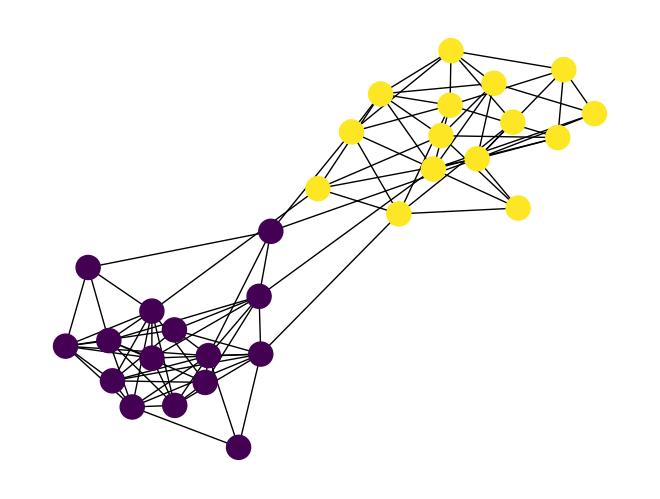

In [6]:
# Интересно....
nx.draw(G2, node_color=labels2)

**Интерпретация:**

- Граф с двумя кластерами, где p_in = 0.4 (внутри кластера связи частые) и p_out = 0.02 (между кластерами связи редкие): узлы одного класса тесно связаны между собой и слабо - с другим классом  
- Исходные признаки X2 - только степень узла (нормированная) и константа - сами по себе не разделяют классы идеально, так как степени узлов в обоих кластерах могут перекрываться  
- После одного шага нормализованного GCN (агрегация признаков соседей с учётом собственной вершины и симметричной нормализации) эмбеддинги H2 начинают группироваться по классам. Это видно на `nx.draw(G2, node_color=labels2)` точки класса 0 и класса 1 образуют компактные и разделимые облака  
- В пространстве признаков разделимость признаков практически не наблюдается  
- При случайных весах W2 агрегация "усредняет" признаки внутри кластера (из-за высокой внутренней связности) и ослабляет влияние между кластерами. В результате узлы одного класса становятся похожи друг на друга в скрытом пространстве   
- Один слой GCN без обучения уже способен делать узлы одного кластера более схожими если граф имеет хорошую кластерную структуру  

---

# СРЕДНИЕ ЗАДАЧИ (5–7)

Теперь будем обучать GCN и GraphSAGE на узловой задаче и сравнивать их результаты.


## Задача 5. Обучение простого GCN для классификации узлов

### Постановка задачи

1. Реализовать один GCN-слой в PyTorch с использованием нормализованной матрицы смежности.
2. Собрать из него простую модель с двумя слоями для классификации узлов на синтетическом графе.
3. Обучить модель и оценить качество на обучающем и тестовом подмножествах узлов.

### Теоретический минимум

- GCN-слой: $H^{(l+1)} = \sigma(\tilde{A} H^{(l)} W^{(l)})$.
- В узловой задаче разделение на train / test обычно делается по узлам, а не по графам.


In [7]:
# Задача 5. Реализация и обучение GCN

# --- Шаг 1. Подготовка данных ---
def numpy_to_torch(x):
    return torch.from_numpy(x).float()

# DONE: Конвертируйте A2_norm, X2, labels2 в тензоры и перенесите на DEVICE
A2_norm_t = numpy_to_torch(A2_norm).to(DEVICE)
X2_t = numpy_to_torch(X2).to(DEVICE)
labels2_t = torch.from_numpy(labels2).long().to(DEVICE)

# --- Шаг 2. Разбиение узлов ---
# DONE: Перемешайте индексы и разделите на train (70%) и test (30%)
idx = np.arange(num_nodes2)
np.random.shuffle(idx)
split = np.int32(0.7 * num_nodes2)
idx_train = idx[:split]
idx_test = idx[split:]

# --- Шаг 3 & 4. Архитектура модели ---
class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        # DONE: инициализируйте линейный слойs
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, x, A_norm):
        # DONE: умножьте A_norm @ x, затем примените линейный слой
        Ax = A_norm @ x
        return self.linear(Ax)

class GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        # DONE: два слоя GCNLayer
        self.layer1 = GCNLayer(in_dim, hidden_dim)
        self.layer2 = GCNLayer(hidden_dim, out_dim)

    def forward(self, x, A_norm):
        # DONE: первый слой → ReLU → второй слой
        h = torch.relu(self.layer1(x, A_norm))  # ReLU - функция активации, я обязательно запомню
        return self.layer2(h, A_norm)

# --- Шаг 5. Оптимизатор и функция потерь ---
model_gcn = GCN(in_dim=2, hidden_dim=16, out_dim=2).to(DEVICE)
# DONE: настройте Adam (lr=0.01, weight_decay=5e-4) и CrossEntropyLoss
optimizer = torch.optim.Adam(model_gcn.parameters(),
                             lr=0.01,
                             weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

# --- Шаг 6. Цикл обучения ---
EPOCHS = 200

for epoch in range(EPOCHS):
    model_gcn.train()
    optimizer.zero_grad()
    # DONE: forward pass
    logits = model_gcn(X2_t, A2_norm_t)
    # DONE: потеря только по обучающим узлам
    loss = criterion(logits[idx_train], labels2_t[idx_train])
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 40 == 0:
        model_gcn.eval()
        with torch.no_grad():
            # DONE: вычислите train_acc и test_acc
            pred = logits.argmax(dim=1)
            train_acc = (
                (pred[idx_train] == labels2_t[idx_train]).float().mean().item()
            )
            test_acc = (
                (pred[idx_test] == labels2_t[idx_test]).float().mean().item()
            )
        print(f"[GCN] Эпоха {epoch+1:3d},",
              f"loss = {loss.item():.4f},",
              f"train_acc = {train_acc:.2f},",
              f"test_acc = {test_acc:.2f}")

[GCN] Эпоха  40, loss = 0.6016, train_acc = 0.86, test_acc = 0.78
[GCN] Эпоха  80, loss = 0.3707, train_acc = 0.95, test_acc = 1.00
[GCN] Эпоха 120, loss = 0.1775, train_acc = 0.95, test_acc = 1.00
[GCN] Эпоха 160, loss = 0.1077, train_acc = 0.95, test_acc = 1.00
[GCN] Эпоха 200, loss = 0.0761, train_acc = 0.95, test_acc = 1.00


**Интерпретация:**

 - Все тензоры (`A_norm`, `X`, `labels`) должны быть на одном устройстве (CPU/GPU), иначе получаю ошибку  
 - Разбиение узлов d - перемешиваю индексы, чтобы распределение классов было практичекси равномерным  
 - `GCNLayer d` - сначала агрегация $A\_norm \cdot x$, затем линейный слой. Именно так, а не иначе  
 - `Два слоя d` - первый слой с ReLU даёт нелинейность, второй d - логиты для двух классов  
 - После обучения вычисляю argmax по логитам и сравниваю с метками; accuracy считается отдельно для train и test  
 - Регуляризация d в Adam помогает обобщению  
___

## Задача 6. Реализация и обучение упрощенного GraphSAGE

### Постановка задачи

1. Реализовать слой GraphSAGE с mean-агрегацией соседей.
2. Обучить модель GraphSAGE на той же задаче классификации узлов и с тем же разбиением.
3. Сравнить результаты с GCN по точности и стабильности обучения.

### Теоретический минимум

- GraphSAGE агрегирует соседей по формуле
  $h_i^{(l+1)} = \sigma\bigl(W_1 h_i^{(l)} + W_2 \cdot \mathrm{mean}_{j \in \mathit{N}(i)} h_j^{(l)}\bigr)$.
- В отличие от GCN, здесь агрегация задается явно, что удобно для индуктивных задач.

In [8]:
# Задача 6. Реализация и обучение GraphSAGE

# --- Шаг 1. Списки соседей ---
# DONR: Создайте список neighbors_list, где neighbors_list[i] — список соседей узла i
neighbors_list = [np.where(A2[i] == 1)[0].tolist() for i in range(A2.shape[0])]

# --- Шаги 2–4. Архитектура ---
class GraphSAGELayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        # DONE: два линейных слоя: для собственного признака и для агрегата
        self.linear_self = nn.Linear(in_dim, out_dim)
        self.linear_neigh = nn.Linear(in_dim, out_dim)

    def forward(self, x):
        # x: (N, D)
        N = x.shape[0]
        neigh_agg = torch.zeros_like(x)
        # DONE: для каждого узла i усредните признаки его соседей из neighbors_list[i]
        for i in range(N):
            neighs = neighbors_list[i]
            if len(neighs) > 0:
                neigh_agg[i] = x[neighs].mean(dim=0)
            else:
                neigh_agg[i] = torch.zeros_like(x[0])
        # DONE: верните сумму двух линейных преобразований: self и neigh
        out = self.linear_self(x) + self.linear_neigh(neigh_agg)
        return out

class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        # DONE: два слоя GraphSAGELayer
        self.layer1 = GraphSAGELayer(in_dim, hidden_dim)
        self.layer2 = GraphSAGELayer(hidden_dim, out_dim)

    def forward(self, x):
        # DONE: первый слой → ReLU → второй слой
        x = self.layer1(x)
        x = torch.relu(x)
        x = self.layer2(x)
        return x

# --- Шаг 5. Обучение ---
model_sage = GraphSAGE(in_dim=2, hidden_dim=16, out_dim=2).to(DEVICE)
optimizer_sage = torch.optim.Adam(model_sage.parameters(),
                                  lr=0.01,
                                  weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

EPOCHS_SAGE = 200

for epoch in range(EPOCHS_SAGE):
    model_sage.train()
    optimizer_sage.zero_grad()
    # DONE: forward pass и loss по idx_train
    logits_sage = model_sage(X2_t)
    loss_sage = criterion(logits_sage[idx_train], labels2_t[idx_train])
    loss_sage.backward()
    optimizer_sage.step()

    if (epoch + 1) % 40 == 0:
        model_sage.eval()
        with torch.no_grad():
            # DONE: вычислите train_acc и test_acc для SAGE
            pred_sage = logits_sage.argmax(dim=1)
            train_acc_sage = (
                (pred_sage[idx_train] == labels2_t[idx_train]).float().mean()
            )
            test_acc_sage = (
                (pred_sage[idx_test] == labels2_t[idx_test]).float().mean()
            )
        print(f"[SAGE] Эпоха {epoch+1:3d},",
              f"loss = {loss_sage.item():.4f},",
              f"train_acc = {train_acc_sage:.2f},",
              f"test_acc = {test_acc_sage:.2f}")

[SAGE] Эпоха  40, loss = 0.6565, train_acc = 0.57, test_acc = 0.33
[SAGE] Эпоха  80, loss = 0.3986, train_acc = 0.90, test_acc = 1.00
[SAGE] Эпоха 120, loss = 0.1633, train_acc = 0.95, test_acc = 1.00
[SAGE] Эпоха 160, loss = 0.0721, train_acc = 1.00, test_acc = 1.00
[SAGE] Эпоха 200, loss = 0.0343, train_acc = 1.00, test_acc = 1.00


**Интерпретация:**

 - При создании списка соседей `neighbors_list` важно не использовать петлю для вершины, поскольку mean(neigh) будет включать сам узел, и его вклад продублируется  
 - В отличие от GCN, в GraphSAGE нет нормализации матрицы смежности, а агрегат соседей вычисляется как простое среднее их признаков. Далее идёт собственное преобразование узла (через W1) и преобразование среднего соседей (через W2) складываются и пропускаются через активацию. 
 - При обучении я заметил, что модель GCN отрабатывает гораздо быстрее (быстрее сходится): на 40-й эпохе у него train_acc = 0.86, test_acc = 0.78, тогда как GraphSAGE на том же шаге показывает только 0.57 и 0.33 соответственно. К 80-й эпохе GraphSAGE догоняет GCN по тесту, но обучающая точность всё ещё ниже. К 120–160 эпохам обе модели выходят на 0.95–1.00 по train и 1.00 по test, но абсолютный лидер по loss - это GraphSAGE  
 - На старте GraphSAGE показывает метрики хуже, чем GCN, это связано с отсутствием нормализации в агрегации и раздельными весами для себя и соседей (усложняет начальную оптимизацию).  
 - 

## Задача 7. Сравнение эмбеддингов GCN и GraphSAGE

### Постановка задачи

1. Получить скрытые представления узлов после первого слоя GCN и GraphSAGE.
2. Визуализировать их в двумерном пространстве (например, взять первые две координаты).
3. Проанализировать, какая модель лучше разделяет классы узлов.

### Теоретический минимум

- Эмбеддинги узлов отражают то, как модель видит структуру графа и признаки.
- В хорошей модели эмбеддинги узлов одного класса образуют кластеры.


In [9]:
# TODO: удалить
# Ячейка для экспериментов и проб



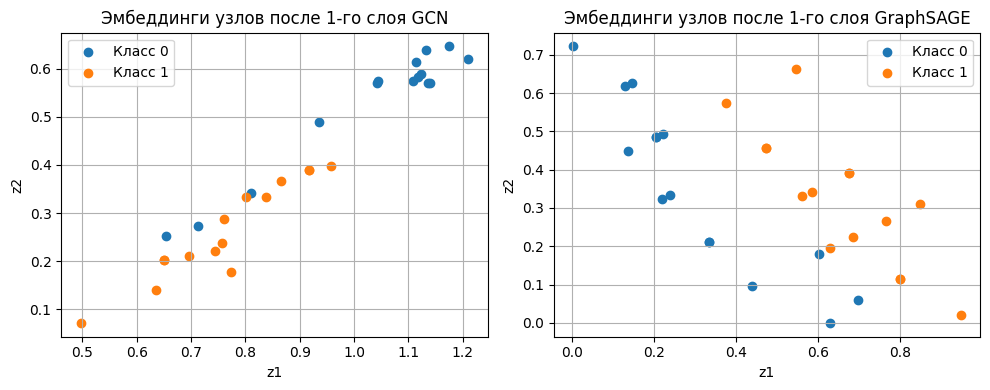

In [10]:
# Задача 7. Визуализация и сравнение эмбеддингов

model_gcn.eval()
model_sage.eval()

with torch.no_grad():
    # DONE: получите эмбеддинги после первого слоя GCN (с ReLU)
    # Обратитесь напрямую к model_gcn.gcn1 с нужными аргументами
    h_gcn1 = model_gcn.layer1(X2_t, A2_norm_t)
    h_gcn1 = torch.relu(h_gcn1)

    # DONE: получите эмбеддинги после первого слоя GraphSAGE (с ReLU)
    h_sage1 = model_sage.layer1(X2_t)
    h_sage1 = torch.relu(h_sage1)

# DONE: Переведите тензоры в numpy
h_gcn_np = h_gcn1.cpu().numpy()
h_sage_np = h_sage1.cpu().numpy()

# DONE: Постройте два scatter plot рядом (1 строка, 2 колонки):
# Левый — GCN, правый — GraphSAGE
# Для каждого класса (0 и 1) отдельный цвет
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(h_gcn_np[:15, 0], h_gcn_np[:15, 1], label='Класс 0')
plt.scatter(h_gcn_np[15:, 0], h_gcn_np[15:, 1], label='Класс 1')
plt.title("Эмбеддинги узлов после 1-го слоя GCN")
plt.xlabel("z1"); plt.ylabel("z2")
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
#  первые 15 — класс 0, вторые 15 — класс 1
plt.scatter(h_sage_np[:15, 0], h_sage_np[:15, 1], label='Класс 0')
plt.scatter(h_sage_np[15:, 0], h_sage_np[15:, 1], label='Класс 1')
plt.title("Эмбеддинги узлов после 1-го слоя GraphSAGE")
plt.xlabel("z1"); plt.ylabel("z2")
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

**Интерпретация:**

- Шаблонного вывода мне достичь не удалось, подореваю, что где-то ошибка. Предзаполненный ноутбук очень помогает понять, что мне требуется сделать  
- По визуализации видно, что эмбеддинги после первого слоя `GCN` и `GraphSAGE` различаются по степени разделения классов
    - **GCN (левый график):**
        - Оба класса выстроены в одну линию  
        - Кластеры классов 0 и 1 частично перекрываются, но заметна тенденция к разделению  
        - Большинство точек внутри каждого класса расположены компактно
        - Граница между классами нечёткая  

    - **GraphSAGE (правый график):**
        - Кластеры хорошо разделены  
        - Точки одного класса лежат ближе друг к другу  
        - Расстояние между классами явно различимо  
    
    - На этапе после первого слоя `GraphSAGE` формирует более выразительные и разделимые эмбеддинги, чем `GCN`. Это связано с тем, что в `GraphSAGE` используются отдельные веса для собственного признака и для агрегата соседей, что даёт модели больше гибкости при обучении. `GCN` с общей нормализацией быстрее сходится по loss, но его скрытые представления на раннем слое оказываются менее контрастными  

Для визуального анализа и, возможно, для последующей классификации на промежуточных слоях `GraphSAGE` выглядит предпочтительнее, однако, финальная точность обеих моделей в задаче классификации оказалась одинаково высокой для данного примера   

---

# СЛОЖНЫЕ ЗАДАЧИ (8–9)

Теперь перейдем к graph-level задачам с использованием pooling и сделаем
итоговое сравнение моделей.


## Задача 8. Graph-level классификация с pooling

### Постановка задачи

1. Сгенерировать набор синтетических графов двух разных классов (например, более разреженные и более плотные).
2. Для каждого графа задать признаки узлов и применить один шаг message passing (GCN или GraphSAGE).
3. Выполнить global mean pooling для получения эмбеддинга графа и обучить простой MLP-классификатор.

### Теоретический минимум

- В graph-level задачах агрегация по узлам (readout / pooling) превращает переменное число узлов
  в фиксированный вектор признаков графа.


In [ ]:
# Задача 8. Реализация graph-level классификации
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# --- A. Генерация данных ---

num_graphs_per_class = 40
num_nodes_min, num_nodes_max = 10, 15

graphs = []
labels_graph = []

for cls in [0, 1]:
    for _ in range(num_graphs_per_class):
        n = np.random.randint(num_nodes_min, num_nodes_max + 1)
        # TODO: Выберите вероятность ребра p в зависимости от cls (0 → разреженный, 1 → плотный)
        p = ...
        # TODO: Сгенерируйте граф Эрдёша–Реньи
        Gg = ...
        # TODO: Если граф не связный, возьмите наибольшую компоненту связности
        if not nx.is_connected(Gg):
            Gg = ...
        graphs.append(Gg)
        labels_graph.append(cls)

labels_graph = np.array(labels_graph, dtype=np.int64)

# --- B. Graph embedding через GCN + mean pooling ---

def graph_embedding_gcn_like(Gg):
    """
    Вычисляет эмбеддинг графа через один нормализованный шаг GCN и mean pooling.

    Возвращает:
        h_graph: np.ndarray формы (out_dim,)
    """
    A = nx.to_numpy_array(Gg, dtype=np.float32)
    n = A.shape[0]

    # TODO: Постройте матрицу признаков X: константа + нормированная степень (форма n x 2)
    X = ...

    # TODO: Нормализованная матрица смежности (аналогично Задаче 3)
    A_norm = ...

    # TODO: Случайная матрица весов W формы (2, 4), масштаб ~0.1
    W = ...

    # TODO: H = ReLU(A_norm @ X @ W)
    H = ...

    # TODO: Mean pooling: усредните H по всем узлам → вектор формы (4,)
    h_graph = ...
    return h_graph

# Применяем функцию ко всем графам
X_graph = np.stack([graph_embedding_gcn_like(Gg) for Gg in graphs], axis=0)
print("Форма X_graph:", X_graph.shape)

# --- C. Обучение классификатора ---

# TODO: Разбейте X_graph и labels_graph на train/test (test_size=0.3, stratify=labels_graph)
X_train_g, X_test_g, y_train_g, y_test_g = ...

class GraphMLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        # TODO: nn.Sequential с двумя Linear слоями и ReLU между ними
        self.net = ...

    def forward(self, x):
        return self.net(x)

model_graph = GraphMLP(in_dim=4, hidden_dim=16, out_dim=2).to(DEVICE)
optimizer_graph = torch.optim.Adam(model_graph.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

# TODO: Конвертируйте X_train_g, X_test_g, y_train_g, y_test_g в тензоры PyTorch
X_train_t = ...
X_test_t = ...
y_train_t = ...
y_test_t = ...

EPOCHS_GRAPH = 200

for epoch in range(EPOCHS_GRAPH):
    model_graph.train()
    optimizer_graph.zero_grad()
    # TODO: forward pass и loss
    logits_g = ...
    loss_g = ...
    loss_g.backward()
    optimizer_graph.step()

    if (epoch + 1) % 50 == 0:
        model_graph.eval()
        with torch.no_grad():
            # TODO: вычислите train_acc и test_acc
            ...
        print(f"Эпоха {epoch+1:3d}, loss = {loss_g.item():.4f}, train_acc = {train_acc_g:.2f}, test_acc = {test_acc_g:.2f}")

**Интерпретация:**

## Задача 9. Итоговое сравнение GCN, GraphSAGE и graph-level модели

### Постановка задачи

1. Сравнить точность GCN и GraphSAGE на узловой задаче.
2. Сравнить точность graph-level модели на задачах классификации графов.
3. Сформулировать выводы: какая архитектура лучше подходит для какой постановки,
   как влияют глубина и тип агрегации.

### Теоретический минимум

- Разные архитектуры GNN по-разному используют структуру графа и признаки.
- Выбор модели зависит от типа задачи (узловая vs графовая) и требований
  к индуктивности и масштабируемости.


In [ ]:
# Задача 9. Сводка метрик

# --- Узловая задача ---
model_gcn.eval()
model_sage.eval()

with torch.no_grad():
    # TODO: вычислите финальные train_acc и test_acc для GCN
    logits_gcn = ...
    pred_gcn = ...
    train_acc_gcn = ...
    test_acc_gcn = ...

    # TODO: вычислите финальные train_acc и test_acc для GraphSAGE
    logits_sage = ...
    pred_sage = ...
    train_acc_sage = ...
    test_acc_sage = ...

# --- Graph-level задача ---
model_graph.eval()
with torch.no_grad():
    # TODO: вычислите финальные train_acc и test_acc для graph-level модели
    ...
    train_acc_graph = ...
    test_acc_graph = ...

# --- Сводная таблица ---
print("=" * 60)
print(f"{'Модель':<25} {'train_acc':>10} {'test_acc':>10}")
print("=" * 60)
print(f"{'GCN (узловая)':<25} {train_acc_gcn:>10.3f} {test_acc_gcn:>10.3f}")
print(f"{'GraphSAGE (узловая)':<25} {train_acc_sage:>10.3f} {test_acc_sage:>10.3f}")
print(f"{'Graph MLP + pooling':<25} {train_acc_graph:>10.3f} {test_acc_graph:>10.3f}")
print("=" * 60)



**Интерпретация:**


---

## Интерпретация результатов

В этом задании:

- мы увидели, как граф задается через матрицу смежности и матрицу признаков,
  и как базовые линейные операции реализуют message passing;
- реализовали нормализованный шаг GCN и проверили согласованность размерностей;
- обучили простую GCN-модель для классификации узлов и убедились, что структура графа
  помогает улучшить качество;
- реализовали упрощенный GraphSAGE и сравнили его поведение с GCN по качеству и
  эмбеддингам узлов;
- построили простую graph-level модель на основе одного шага message passing и pooling
  и показали, что она умеет различать классы графов.

Мы также увидели, что выбор архитектуры (GCN vs GraphSAGE) и типа pooling влияет
на разделимость классов и поведение модели на узловых и графовых задачах.


## Выводы

1. Графовые нейронные сети опираются на простые матричные операции (умножение на матрицу смежности
   и линейные преобразования), которые реализуют шаги message passing.
2. GCN использует фиксированную нормализованную матрицу \(	ilde{A}\), что делает слой компактным и
   удобным для трандуктивных задач.
3. GraphSAGE задает агрегацию соседей явно и хорошо подходит для индуктивных сценариев, где
   граф может меняться или расширяться.
4. Для graph-level задач критично использовать pooling, который агрегирует признаки узлов
   в фиксированный вектор представления графа.
5. Практический выбор архитектуры зависит от постановки: для узловых задач с фиксированным графом
   удобно использовать GCN, для более гибких сценариев и больших графов — варианты GraphSAGE,
   а для задач на графах — комбинации message passing и pooling.
